<a href="https://colab.research.google.com/github/CatCan55/Non-Boolean-Quantum-Amplitude-Amplification/blob/main/Project_2_Catherine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
%pip install qiskit # needed in colab
%pip install pylatexenc
import pylatexenc

from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit import barrier


import numpy as np
import sympy as sp

Non-boolean amplitude amplification algorithm

1. initialize |��⟩ := |��0⟩
2. for k:= 1 to K do
3. if k is odd then
4. update |��⟩ := S��0 U�� |��⟩
5. else
6. update |��⟩ := S��0 U†�� |��⟩
7. end if
8. end for
9. Measure the ancilla in the 0/1 basis.


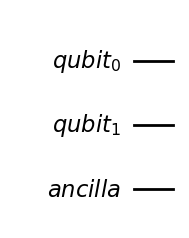

In [7]:
num_qubits = 2
qubit = QuantumRegister(num_qubits, 'qubit')
ancilla = AncillaRegister(1, 'ancilla')

circuit_1 = QuantumCircuit(qubit, ancilla)

# first we initialize, taking A_0 = H here
circuit_1.h

display(circuit_1.draw('mpl'))

Apply U_phi when k is odd. Apply U_phi_adj when k is even.

In [ ]:
N = 2 ** num_qubits
# Define a function of range [0,1]
def g(x):
    return np.sin(x)**2

# Compute the diagonal entries of the phase oracle matrix
diagonal_entries = [np.exp(1j * np.pi * g(x)) for x in range(N)]

# Create the diagonal matrix for the phase oracle
diagonal_matrix = np.diag(diagonal_entries)

# Create the phase oracle operator
phase_oracle = Operator(diagonal_matrix)

phase_oracle_adjoint = phase_oracle.adjoint()

sp.Matrix(phase_oracle.data) # Display the matrix with numerical values

In [ ]:
odd_gate = U_phi_circuit.to_gate(label='U_phi')

In [ ]:
# Circuit for the adjoint of U_phi

U_phi_adjoint_circuit = U_phi_circuit.inverse()

In [ ]:
even_gate = U_phi_adjoint_circuit.to_gate(label='U_phi^+')

In [ ]:
q1 = QuantumRegister(2, 'q1')
a1 = AncillaRegister(1, 'a1')
odd_iteration_circuit = QuantumCircuit(q1, a1)
# odd_iteration_circuit.append(odd_gate, [q1[0], a1[0]])
# odd_iteration_circuit.append(diffuser_gate, [q1[0], a1[0]])

# display(odd_iteration_circuit.draw('mpl'))

In [ ]:
q2 = QuantumRegister(2, 'q2')
a2 = AncillaRegister(1, 'a2')
even_iteration_circuit = QuantumCircuit(q2, a2)
# even_iteration_circuit.append(even_gate, [q1[0], a1[0]])
# even_iteration_circuit.append(diffuser_gate, [q1[0], a1[0]])